In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.linewidth'] = 1.1

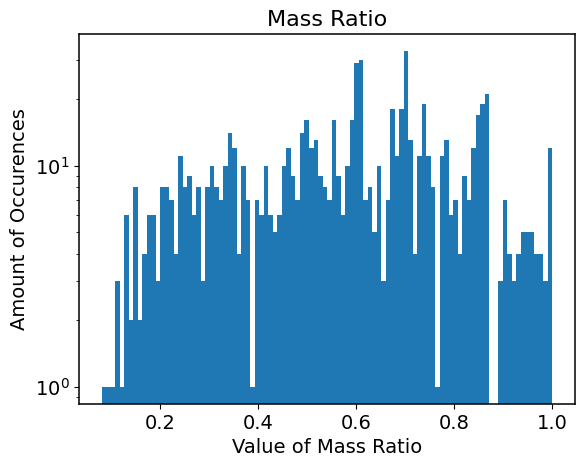

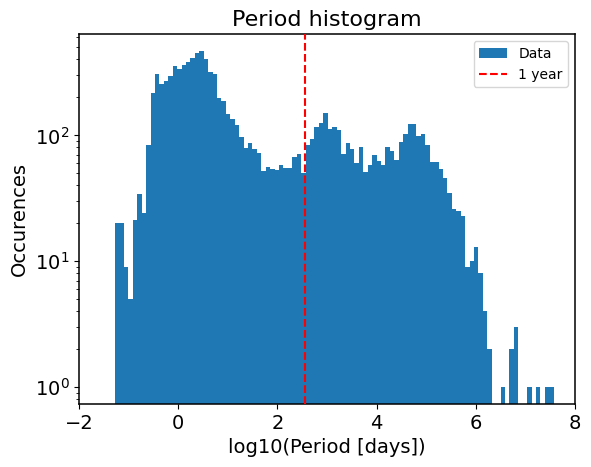

In [14]:
df = pd.read_csv(r'DATA/RAW/reduced_raw_data.csv')
eccentricity = df["e"]
mass_ratio = df["q"]
period = df["period"]
semi_major_ax = df["a"]
id = df["system_id"]

plt.hist(mass_ratio, log=True, bins=100)
plt.xlabel('Value of Mass Ratio')
plt.ylabel('Amount of Occurences')
plt.title('Mass Ratio')
plt.show()


bins = np.linspace(np.log10(period.min()),
                   np.log10(period.max()),
                   100)
plt.hist(np.log10(period), log=True, bins=bins,density=False, label= 'Data')
plt.xlabel('log10(Period [days])')
plt.ylabel('Occurences')
plt.title('Period histogram')
plt.xlim(-2,8)
plt.axvline(np.log10(365), color = 'red', linestyle = 'dashed', zorder = 45, label = '1 year')
plt.legend()
plt.show()

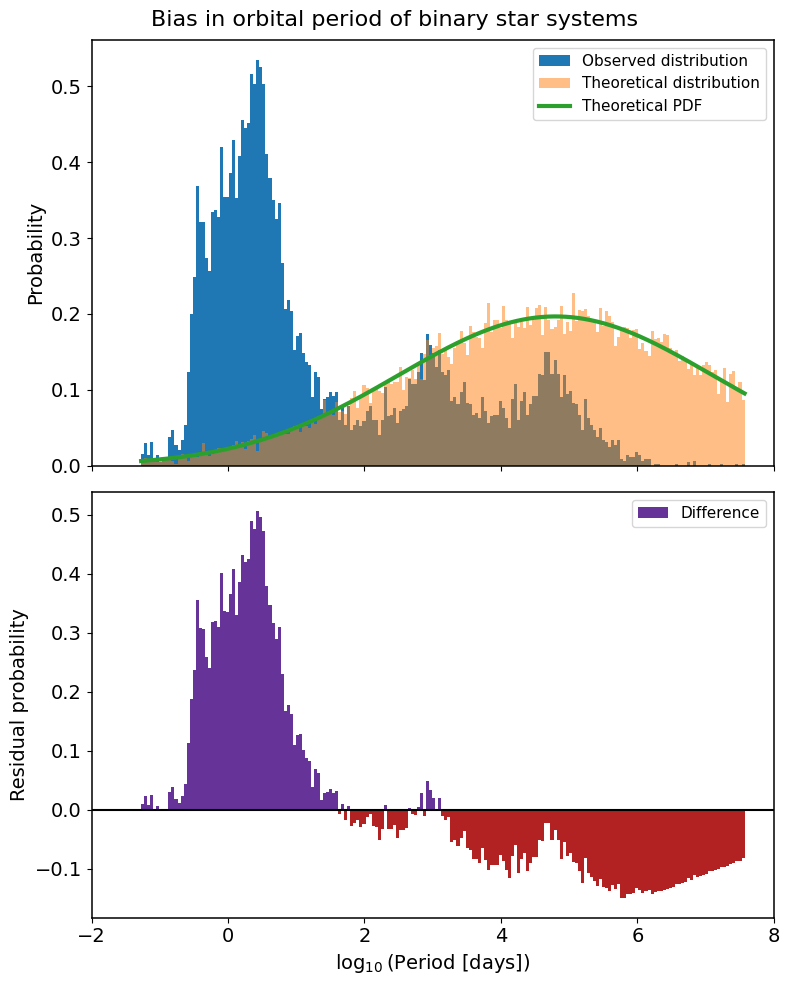

In [15]:
#Duquennoy & Mayor (1991) https://academic.oup.com/mnras/article/417/3/1684/1084726?login=true
#https://ui.adsabs.harvard.edu/abs/1991A&A...248..485D 
#Bias in short periods, because we have simply not looked at certain binary star systems long enough, thus we do not see a period or half
#And for long periods we have way weaker radial velocity signals, thus making them harder to spot

#Look at the amount of bins

def log_per_dist(lP):
    mu = 4.8
    sig = 2.3
    return 1/(sig*np.sqrt(2*np.pi)) * np.exp(-(lP-mu)**2/(2*sig**2))

N = 200
bins = np.linspace(np.log10(period.min()),np.log10(period.max()),N)

Pers = np.linspace(np.log10(period.min()),np.log10(period.max()),len(period))

# Observed histogram
hist_dat, bin_edges = np.histogram(np.log10(period),bins=bins,density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Compute probabilities
p = log_per_dist(Pers)

# Normalize probabilities
p = p / p.sum()

# Sample according to theoretical distribution
samples = np.random.choice(Pers, size=len(period), p=p)

# Theoretical histogram
#dist_dat, dist_edges = np.histogram(samples,bins=bins,density=True)
dist_dat = log_per_dist(bin_centers)

hist_diff = hist_dat - dist_dat

# Create 2 stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(8, 10),sharex=True)

#Top subplot
ax1.hist(np.log10(period),log=True,bins=bins,density=True,label='Observed distribution')

ax1.hist(samples,bins=bins,density=True,alpha=0.5,label='Theoretical distribution')

#Plot normalized PDF
ax1.plot(Pers,p / (Pers[1] - Pers[0]),label='Theoretical PDF', lw =3)

ax1.set_xlim(-2, 8)
ax1.set_yscale('linear')

ax1.set_ylabel('Probability')
ax1.legend(fontsize = 11)

#Bottom subplot
colors = ['rebeccapurple' if v > 0 else 'firebrick' for v in hist_diff]
ax2.bar(bin_centers,hist_diff,width=np.diff(bin_edges),color=colors,align='center',label='Difference')

ax2.axhline(0, color='black')

ax2.set_xlim(-2, 8)

ax2.set_xlabel(r'$\log_{10}$(Period [days])')
ax2.set_ylabel('Residual probability')
ax2.legend(fontsize = 11)

plt.suptitle('Bias in orbital period of binary star systems', size = 16)
plt.tight_layout()
plt.savefig("Period bias.svg")
plt.show()

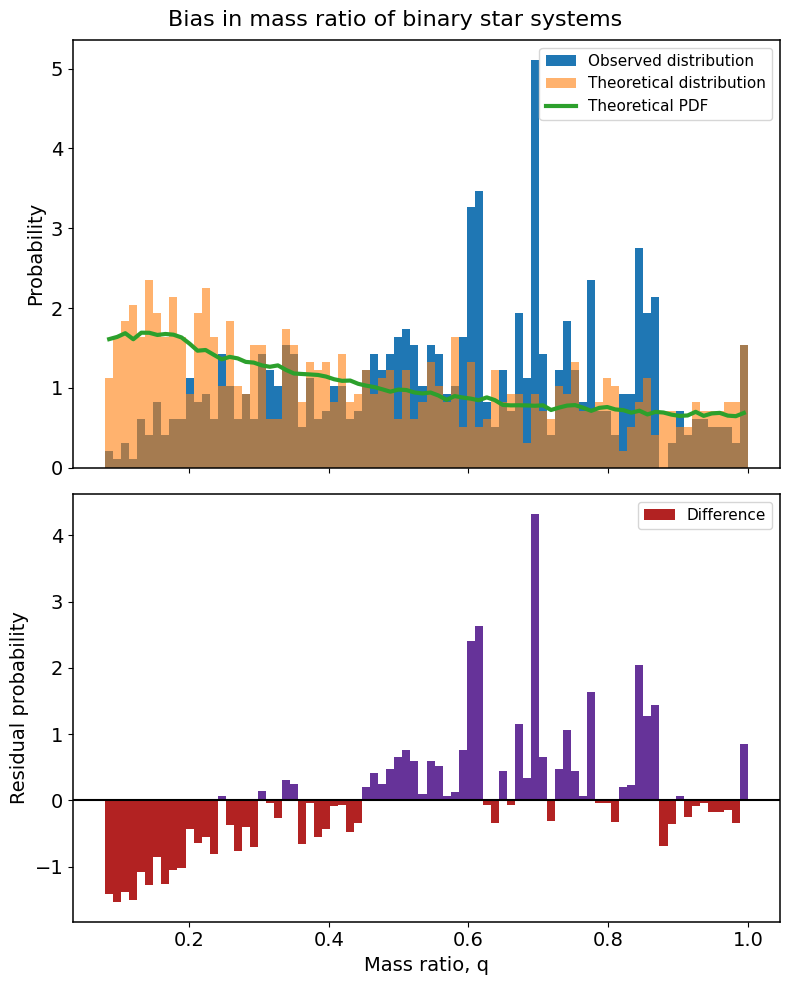

In [16]:
#Bias in Mass ratio, for low ratios. One star is just that much heavier
#To find the ratio, you must have radial velocity data of both stars.
#One of the stars might not be visible, or entirely overshadowed by its more massive companion
#Mass ratio probably goes with q^gamma. Gamma is a bit unknown, probably around -0.3.
#But there might also be an added gaussian term for ratios around 1
#It is at least higher than the -1.35 of the Salpeter IMF
#https://arxiv.org/abs/1606.05347
#We do not have many datapoints for the mass ratio

#Look at the amount of bins and the value for gamma

from scipy.interpolate import interp1d
file_path = "DATA/RAW/q_mass_ratio_distribution.csv"

df = pd.read_csv(file_path)

#PDF
q = df["q"].values
pdf = df["PDF"].values
N = 80

#Raw data
mass_ratio = np.asarray(mass_ratio, dtype=float)
mass_ratio = mass_ratio[np.isfinite(mass_ratio)]

q_dat, q_bin_edges = np.histogram(mass_ratio, bins=N, density=True)

q_bin_centers = (q_bin_edges[:-1] + q_bin_edges[1:]) / 2

#Interpolate PDF and draw random samples from it
PDF_func = interp1d(q, pdf, kind='linear',fill_value="extrapolate")
new_pdf = PDF_func(q_bin_centers)
pdf_2 =  PDF_func(q_bin_edges)
pdf_2 = pdf_2/pdf_2.sum()

q_samples = np.random.choice(q_bin_edges, size=len(mass_ratio), p=pdf_2)

q_diff = q_dat - new_pdf

#Plotting
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(8, 10),sharex=True)

#Top plot
ax1.hist(mass_ratio, bins = N, density=True, label='Observed distribution')
ax1.hist(q_samples, bins=80, density=True, alpha=0.6, label='Theoretical distribution')
ax1.plot(q_bin_centers, new_pdf, label = 'Theoretical PDF', lw = 3)


ax1.set_ylabel('Probability')
ax1.legend(fontsize = 11)

#Bottom plot
colors = ['rebeccapurple' if v > 0 else 'firebrick' for v in q_diff]
ax2.bar(q_bin_centers, q_diff, width=np.diff(q_bin_edges), color = colors, align='center', label = 'Difference')
ax2.axhline(0, color='black')

ax2.set_xlabel('Mass ratio, q')
ax2.set_ylabel('Residual probability')
ax2.legend(fontsize = 11)

plt.suptitle('Bias in mass ratio of binary star systems', size = 16)
plt.tight_layout()
plt.savefig("Mass ratio bias.svg")
plt.show()